In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter

from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset(subset_size=2_000)
qm9.load(force_process=True)
qm9.df.head(5)

2026-03-23 17:36:21.468 | INFO     | src.datasets:_process_raw_qm9:420 - Processing raw QM9 data (Limit: 2000)...
2026-03-23 17:36:30.546 | INFO     | src.datasets:_process_raw_qm9:444 - Stratified sampling enabled. Selected 2200 indices from QM9.
2026-03-23 17:37:16.808 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-23 17:37:33.718 | SUCCESS  | src.datasets:add_soap:623 - Added SOAP embeddings.
2026-03-23 17:37:33.718 | INFO     | src.features:compute_acsf:190 - Computing ACSF (rcut=6.0)...
2026-03-23 17:37:46.590 | SUCCESS  | src.datasets:add_acsf:634 - Added ACSF embeddings.
2026-03-23 17:37:46.591 | INFO     | src.features:compute_coulomb_matrix:224 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-23 17:37:58.246 | SUCCESS  | src.datasets:add_coulomb_matrix:651 - Added Coulomb matrix descriptors.
2026-03-23 17:37:58.249 | WARNING  | src.datasets:_process_raw_qm9:478 - Invalid molecules (SOAP+ACSF+Co

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-23 17:38:23.888 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-23 17:38:24.565 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-23 17:38:24.566 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-23 17:38:27.461 | SUCCESS  | src.datasets:add_all_descriptors:709 - Finished adding all requested descriptors.
2026-03-23 17:38:27.933 | SUCCESS  | src.datasets:_process_raw_qm9:549 - Saved processed dataset with 2000 rows to data/QM9/dataset_cleaned.parquet


mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,acsf_embedding,coulomb_matrix,morgan_fingerprint,selfies_transformer,selfies_onehot,chemprop_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],list[f64],list[i8],list[f64],list[list[i64]],list[f64]
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0.980759,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]","[73.516695, 8.255933, … 0.0]","[0, 0, … 0]","[1.035763, 0.256207, … 0.323382]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.202494, … 0.037565]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""","""""",4,"""Acyclic""",26,0,0,2,0,0,0,1.0,0.0,0.0,0,0,0,2,0,0,3,4,1.105607,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]","[36.858105, 29.992443, … 0.0]","[0, 0, … 0]","[1.47265, 0.608035, … 0.116478]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.254816, … 0.0]"
"""qm9_5""","""CH2O""","""[H]C([H])=O""","""[H]C([H])=O""","""[H][C][Branch1][C][H][=O]""","""""",4,"""Acyclic""",30,0,17,2,0,0,0,0.0,1.0,0.0,0,1,1,0,1,0,2,6,1.129675,0,0,0,0,0,0,0,0,0,0,1,2.1089,14.18,-7.26544,-1.104782,6.157937,59.989101,0.723904,-3115.257812,-3115.179688,-3115.154053,-3115.846924,6.413,-15.557186,-15.633324,-15.710442,-14.763947,285.488403,38.9823,34.29892,"[0.116213, 0.318437, … 0.0]","[1.220346, 0.766063, … 0.0]","[73.516695, 39.195461, … 0.0]","[0, 0, … 0]","[0.107984, 0.565405, … 0.065829]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.297937, … 0.032917]"
"""qm9_9""","""C2H3N""","""[H]C([H])([H])C#N""","""[H]C([H])([H])C#N""","""[H][C][Branch1][C][H][Branch1]…","""""",6,"""Acyclic""",41,0,23,3,0,0,0,0.5,0.0,0.5,0,1,1,1,0,1,3,10,1.182947,0,0,0,0,0,0,0,0,0,0,1,3.8266,24.450001,-8.881797,1.023148,9.904944,160.722305,1.232295,-3611.444824,-3611.347412,-3611.321533,-3612.097656,10.287,-25.576691,-25.710327,-25.838846,-24.159279,159.035675,9.22327,9.22324,"[0.115668, 0.305562, … 0.0]","[1.848344, 1.003772, … 0.0]","[53.358707, 36.199166, … 0.0]","[0, 0, … 0]","[0.224119, 0.309169, … -0.405261]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.17444, … 0.022683]"
"""qm9_10""","""C2H4O""","""[H]C(=O)C([H])([H])[H]""","""[H]C(=O)C([H])([H])[H]""","""[H][C][=Branch1][C][=O][C][Bra…","""""",7,"""Acyclic""",44,0,17,3,0,0,1,0.0,0.5,0.5,0,1,2,0,1,1,3,13,1.185315,0,0,0,0,0,0,0,0,0,0,1,2.5682,25.110001,-6.911692,-0.538785,6.372907,166.972794,1.506286,-4184.773926,-4184.667969,-4184.643066,-4185.45166,11.219,-27.98411,-28.148195,-28.302429,-26.303726,57.224339,10.11122,9.07368,"[0.132639, 0.355143, … 0.0]","[2.437117, 1.08102, … 0.0]","[73.516695, 39.134557, … 0.0]","[0, 0, … 0]","[-0.207652, 0.582814, … 0.100871]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.250029, … 0.025013]"


In [4]:
frames = qm9.get_positions()

2026-03-18 08:32:53.423 | SUCCESS  | src.datasets:get_positions:885 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


In [5]:
qm9.df.filter(pl.col("canonical_smiles").is_duplicated())

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [23]:
mid = qm9.df.height // 2
qm9.df.slice(mid, 5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_62382""","""C9H14""","""[H]C1=C([H])C([H])([H])C(C([H]…","""[H]C1=C([H])C([H])([H])C(C([H]…","""[H][C][=C][Branch1][C][H][C][B…","""""",23,"""Aliphatic Ring""",122,2,0,9,1,0,2,0.0,0.444444,0.555556,0,0,9,0,4,5,6,50,1.239786,0,0,0,0,0,0,0,0,0,0,0,0.5228,93.57,-5.725276,-0.568718,5.159279,1186.459473,5.62092,-9556.043945,-9555.794922,-9555.769531,-9556.958984,36.238998,-96.692917,-97.329971,-97.89547,-89.985992,2.47806,1.46687,1.17288
"""qm9_62438""","""C6H10O3""","""[H]O[C@@]1(C([H])([H])[H])C([H…","""[H]O[C@@]1(C([H])([H])[H])C([H…","""[H][O][C@@][Branch1][=Branch2]…","""alcohol,ester,ether""",19,"""Aliphatic Ring""",130,0,46,9,1,0,2,0.0,0.166667,0.833333,1,3,6,0,1,5,6,39,1.263726,0,1,0,0,0,0,1,0,1,0,3,4.9331,71.57,-6.95523,0.457151,7.412381,1163.076782,4.316351,-12522.990234,-12522.748047,-12522.722656,-12523.901367,33.783001,-79.847275,-80.337189,-80.799843,-74.263313,3.26995,1.22327,1.09757
"""qm9_62442""","""C5H8O4""","""[H]OC1(C([H])([H])[H])C([H])([…","""[H]OC1(C([H])([H])[H])C([H])([…","""[H][O][C][Branch1][=Branch2][C…","""alcohol,ether""",17,"""Aliphatic Ring""",132,0,55,9,1,0,2,0.0,0.2,0.8,1,4,5,0,1,4,6,33,1.27051,0,1,0,0,0,0,0,0,2,0,4,4.8256,64.690002,-7.755245,0.865322,8.620567,1099.856323,3.677918,-13500.758789,-13500.523438,-13500.498047,-13501.670898,31.83,-72.093063,-72.513321,-72.924538,-67.080154,3.45823,1.26148,1.14589
"""qm9_62452""","""C9H18""","""[H]C([H])([H])C1(C([H])([H])[H…","""[H]C([H])([H])C1(C([H])([H])[H…","""[H][C][Branch1][C][H][Branch1]…","""""",27,"""Aliphatic Ring""",126,3,0,9,1,0,4,0.0,0.0,1.0,0,0,9,0,0,9,6,62,1.240676,0,0,0,0,0,0,0,0,0,0,0,0.0324,94.879997,-7.994705,1.904797,9.899502,1348.609009,6.84965,-9621.707031,-9621.425781,-9621.399414,-9622.650391,41.417,-107.902847,-108.661964,-109.33033,-100.065338,2.52064,1.17313,1.11318
"""qm9_62553""","""C7H14NO+""","""[H]O[C@]1(C([H])([H])[H])C([H]…","""[H]O[C@]1(C([H])([H])[H])C([H]…","""[H][O][C@][Branch1][=Branch2][…","""alcohol""",22,"""Aliphatic Ring""",128,-1,24,9,2,0,3,0.0,0.0,1.0,2,1,8,0,0,7,6,51,1.255099,0,1,0,0,0,0,0,0,0,0,2,0.4676,82.970001,-6.234128,2.1497,8.381106,1239.023926,5.249376,-11001.798828,-11001.541016,-11001.515625,-11002.726562,36.365002,-87.87265,-88.463356,-89.003143,-81.444801,2.58203,1.28047,1.08469


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

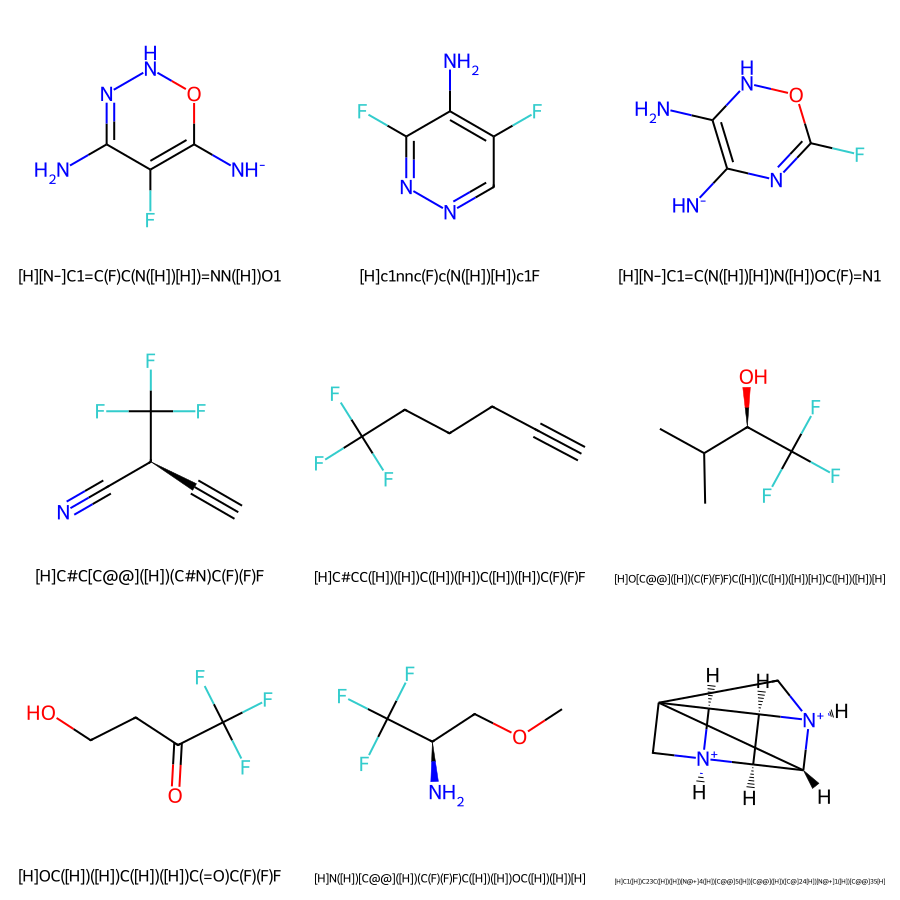

In [7]:
sample_smiles = qm9.df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

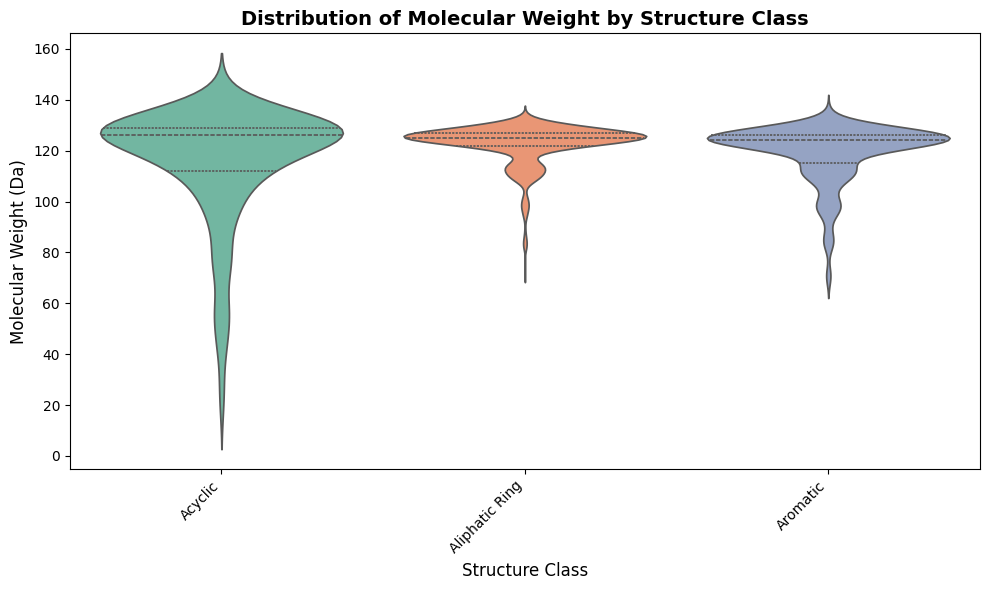

In [8]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=qm9.df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

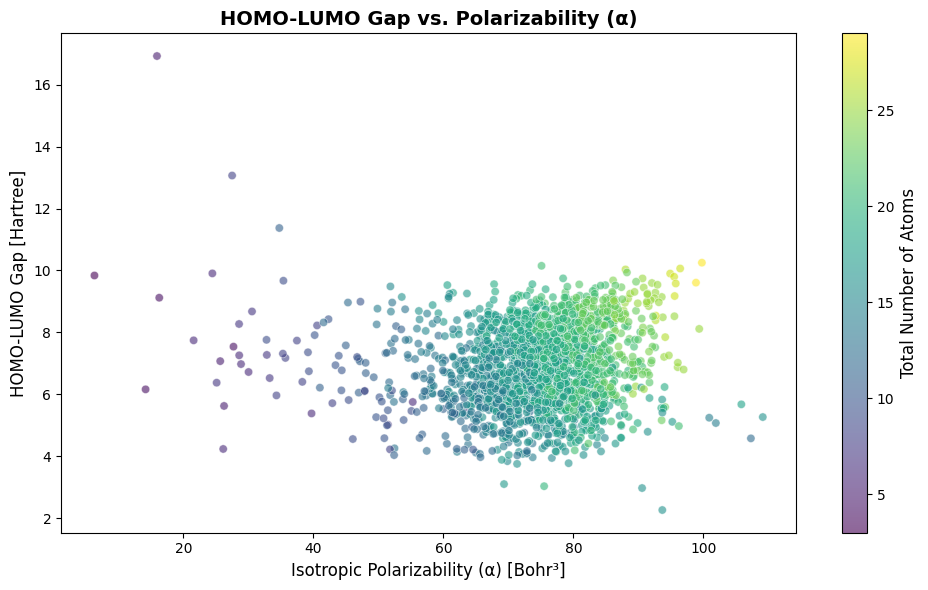

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    qm9.df['alpha'], 
    qm9.df['gap'], 
    c=qm9.df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [Hartree]', fontsize=12)
plt.tight_layout()
plt.show()

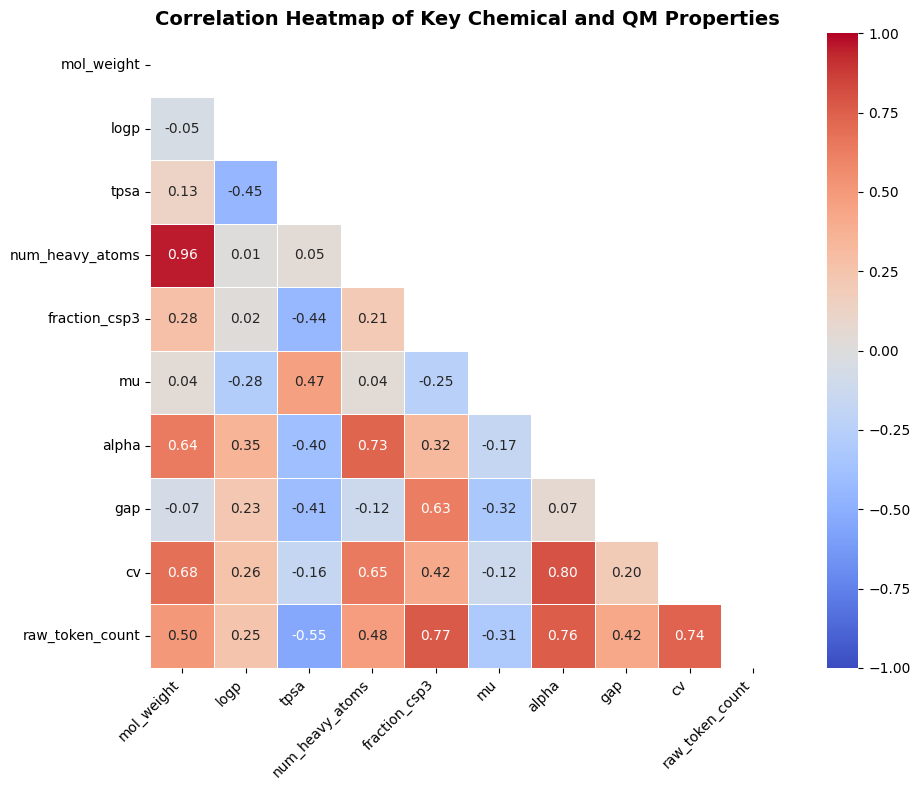

In [11]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = qm9.df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
qm9.df['structure_class']

structure_class
str
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
…
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""


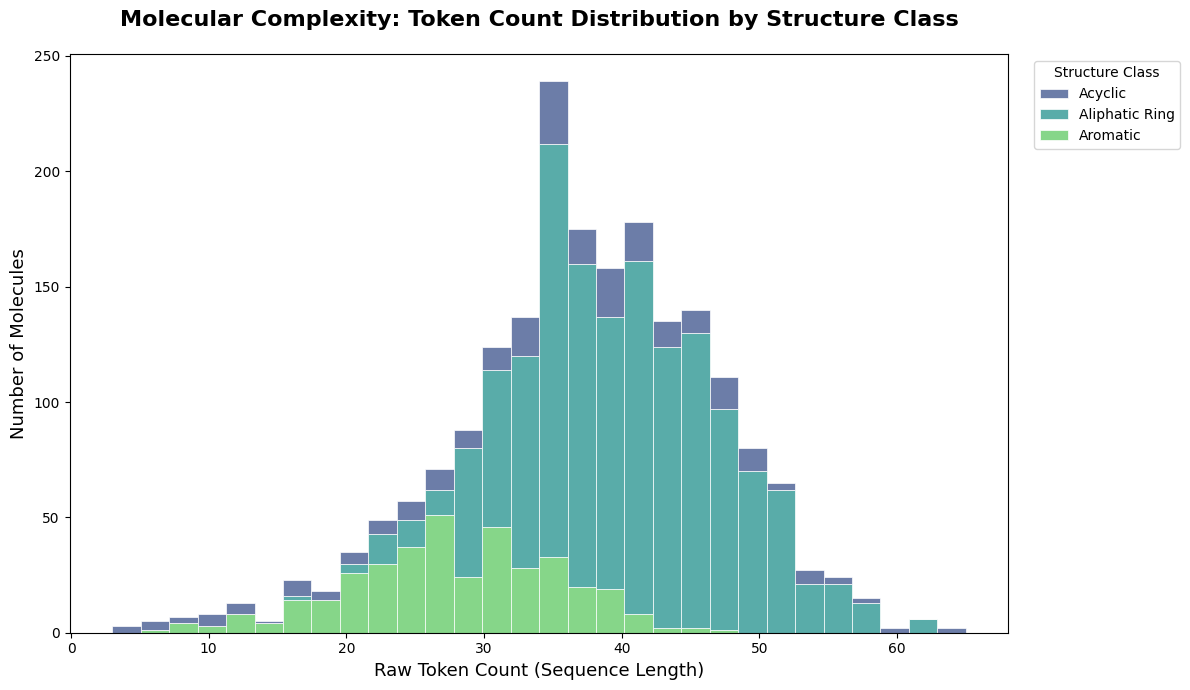

In [13]:
plt.figure(figsize=(12, 7))

# 1. Create the plot (Seaborn creates the legend automatically here)
ax = sns.histplot(
    data=qm9.df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.5,
    bins=30
)

# 2. Access the auto-generated legend and move it
# This avoids the "No artists with labels found" warning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Structure Class')

plt.title('Molecular Complexity: Token Count Distribution by Structure Class', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Raw Token Count (Sequence Length)', fontsize=13)
plt.ylabel('Number of Molecules', fontsize=13)

plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/plot_token_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

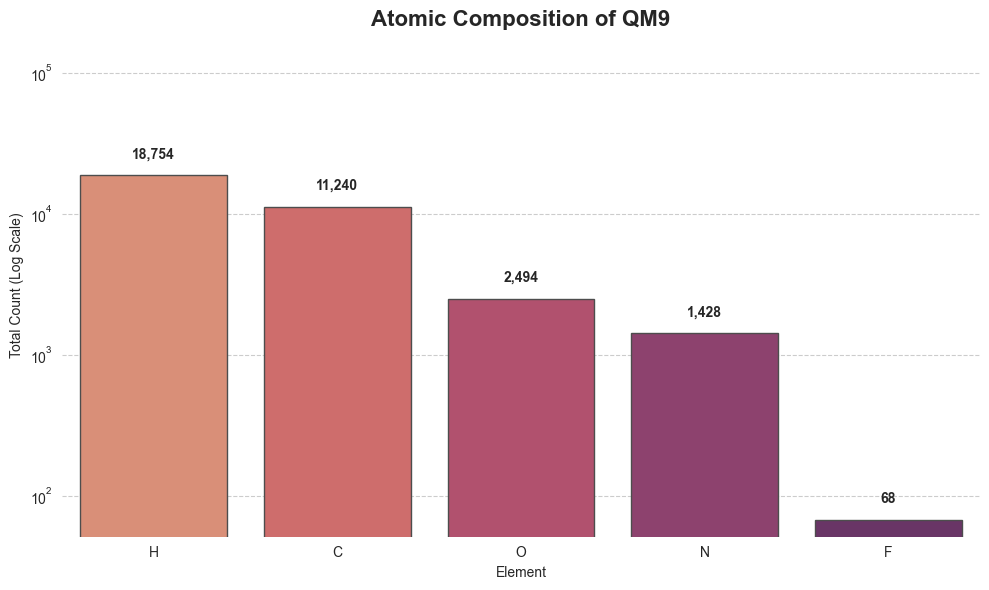

In [14]:
# 1. Processing - Using map(str) to avoid the AttributeError
all_smiles = "".join(map(str, qm9.df["canonical_smiles"]))

# Regex: Find Capital letters followed by optional lowercase (Elements)
# We filter out common SMILES syntax that isn't an element
tokens = re.findall(r'[A-Z][a-z]?', all_smiles)
valid_elements = {'H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'P', 'Br', 'I'}
atom_counts = Counter([t for t in tokens if t in valid_elements])

comp_df = pd.DataFrame(atom_counts.items(), columns=['Element', 'Count'])
comp_df = comp_df.sort_values('Count', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3'
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Added more headroom for labels

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.ylabel('Total Count (Log Scale)')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Average weight of molecule
- Also average bond length

In [15]:
mol_weights = qm9.df['mol_weight']
print(np.average(mol_weights))

121.1865


In [16]:
mol_bond_lengths = qm9.df['avg_bond_length']
plotting = mol_bond_lengths.hist()
plotting

breakpoint,category,count
f64,cat,u32
1.022027,"""[0.980759, 1.022027]""",1
1.063295,"""(1.022027, 1.063295]""",0
1.104563,"""(1.063295, 1.104563]""",0
1.14583,"""(1.104563, 1.14583]""",2
1.187098,"""(1.14583, 1.187098]""",3
1.228366,"""(1.187098, 1.228366]""",92
1.269634,"""(1.228366, 1.269634]""",1210
1.310902,"""(1.269634, 1.310902]""",672
1.35217,"""(1.310902, 1.35217]""",18


In [17]:
qm9.df["smiles"][623]

'[H]C#C[C@@]1([H])C([H])([H])[C@@]2(C#C[H])O[C@@]12[H]'

# Similar Molecules for Grassmann stress test

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

df = qm9.df.to_pandas()
# Assuming your dataframe is named 'df'
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# FIX: Use boolean indexing instead of .filter()
sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

# Generate molecules
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

# Create the grid image
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img